# Inferência Estatística

## Problemas motivadores

1) De 50.000 válvulas fabricadas por uma companhia retira-se uma amostra de 400 válvulas e obtém-se a vida média de 800 horas e o desvio padrão de 100 horas. **(a)** qual o intervalo de confiança de 99% para a vida média da população? **(b)** Com que confiança poderia se dizer que a vida média é 800 $\pm $ 0,98? **(c)** Que tamanho deve ter a amostra para que seja de 95% a confiança na estimativa 800 $\pm $ 7,84?

2) A medida dos diâmetros de uma amostra aleatória de 200 rolamentos esféricos, durante uma semana, apresentam média 0,824 polegadas e o desvio padrão 0,042 polegada. Determine os limites de confiança de **(a)** 95% **(b)** 99%

3) Já sabemos que o problema do lançamento de uma moeda pode ser modelado pela Distribuição Binomial. Supondo o lançamento de uma moeda 50 vezes, suponha que tenha ocorrido 36 caras. Esse resultado permite dizer que a moeda é honesta? O que você faria para verificar esta afirmação?

4) Para fins de estudos, duas turmas de uma determinada disciplina foram comparadas. A primeira turma com 40 alunos, nota média 7,4 e desvio padrão 0,8. A segunda turma com 50 alunos, nota média 7,8 e desvio padrão 0,7. Pergunta-se: há diferença significativa entre os aproveitamentos das duas classes, no nível de significância: **(a)** 0,05 (95%) **(b)** 0,01 (99%).

In [66]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random

In [67]:
amostra = 400
media = 800
desvio = 100/(amostra**0.5)

graus_liberdade = amostra - 1

intervalo_confianca_normal = stats.norm.interval(0.95, loc=media, scale = desvio)
print(intervalo_confianca_normal)

intervalo_confianca = stats.t.interval(0.95, graus_liberdade, loc=media, scale = desvio)
print(intervalo_confianca)

z1 = 0.98/desvio
c1 = stats.norm.cdf(z1)
print(c1)

#inter_desc1 = [799.02,800,800.098]
#c1 = stats.t.cdf(inter_desc1,amostra-1)
#print(c1)

z2 = 7.84/desvio
c2 = stats.norm.cdf(z2)
print(c2)

(790.2001800772997, 809.7998199227003)
(790.170363520396, 809.829636479604)
0.5776949170016281
0.941559433825788


In [68]:
amostra = 200
media = 0.824
desvio = 0.042/(amostra**0.5)

graus_liberdade = amostra - 1

intervalo_95 = stats.t.interval(0.95, graus_liberdade,loc=media, scale = desvio)
print(intervalo_95)

intervalo_confianca_normal = stats.norm.interval(0.95, loc=media, scale = desvio)
print(intervalo_confianca_normal)

intervalo_99 = stats.t.interval(0.99, graus_liberdade,loc=media, scale = desvio)
print(intervalo_99)


(0.8181435878524954, 0.8298564121475045)
(0.8181792039377314, 0.8298207960622686)
(0.816276136223017, 0.8317238637769829)


# Teorema Central do Limite

O teorema central do limite nos diz que, à medida que aumentamos o tamanho desta amostra, a média amostral se aproximará cada vez mais da média populacional. Além disso, a distribuição amostral desta média tenderá a uma distribuição normal e variância igual à variância populacional dividida por n


# Teoria da Amostragem (conceitos breves...)

A teoria da amostragem é um estudos das relações existentes entre uma população e as amostras dela extraídas. É de grande valia para a avaliação de grandezas desconhecidas da população (como sua média, variância e desvio padrão), frequentemente denominadas **_parâmetros populacionais_** ou abreviadamente **_parâmetros_**, através do conhecimento das grandezas correspondentes das amostras (também como média, desvio padrão, etc...) muitas vezes denominadas **_estatísticas amostrais_** ou, abreviadamente **_estatísticas_**.

A teoria da amostragem também é útil para determinar se as difereças observadas entre duas amostras são realmente devidas a uma variação casual ou se são verdadeiramente significativas. Exemplos dessas diferenças são utilizados por exemplo em amostragem de testes clínicos, de produção ou em processos de aferição de qualidade. 

A **_inferência estatística_** nada mais é do que o estudo de uma população a partir de suas amostras, com a indicação da precisão destas inferências baseadas pelo conhecimento da teoria da probabilidade.

**Amostras Aleatórias** são amostras selecionadas (um subconjunto de indivíduos ou objetos) a partir de uma população maior (um grupo completo de indivíduos ou objetos), de forma que cada membro da população tenha uma chance igual de ser escolhido. Tais amostras são desejáveis porque tendem a ser representativas da população e minimizam os vieses na análise.

Pense na amostragem aleatória como um sorteio. Por exemplo, se você quiser estudar as opiniões dos habitantes de uma cidade sobre um tema específico, seria muito difícil e cansativo entrevistar todos os moradores. Então, em vez disso, você pode realizar uma amostragem aleatória, selecionando um número menor de habitantes de forma aleatória e imparcial. Assim, todos os moradores têm a mesma chance de serem escolhidos, e a amostra resultante pode ser usada para inferir informações sobre a população como um todo.

Essa abordagem permite que os pesquisadores façam generalizações e estimativas sobre a população maior com base nos dados coletados da amostra. Quando a amostragem aleatória é realizada corretamente, a amostra tende a refletir as características da população maior, tornando as análises mais precisas e confiáveis.

Há várias técnicas para escolher uma amostra que represente bem a população maior. Aqui, vamos falar sobre quatro dessas técnicas:

- Amostragem Aleatória Simples
- Amostragem Sistemática
- Amostragem Aleatória Estratificada
- Amostragem por Conglomerado

Para muitos casos, tipo a distribuição de médias, o teorema central do limite vai nos ajudar teoricamente, pois sabemos que os dados da ditribuição de amostragem converge para uma normal. Assim, para amostras maiores que 25 ($ N>25$) as amostras tendem a se comportar como uma distribuição normal, e o conhecimento da distribuição normal torna-se útil para facilitar a análise e possíveis inferências sobre a população. Embora se fala muito de big data, na prática, são boas amostras que são utilizadas para responder boas (e a maioria das) perguntas.

## Amostragem aleatória simples

Na amostragem aleatória simples, cada elemento da população tem a mesma chance de ser selecionado. Por exemplo, ao realizar uma pesquisa de opinião, podemos selecionar aleatoriamente um grupo de pessoas para entrevistar. Nesse método, escolhemos um grupo de pessoas ou coisas de forma completamente aleatória, dando a todos na população a mesma chance de serem selecionados.

Para trabalhar a ideia de amostragem, vamos utilizar o arquivo **diamonds.csv**.


In [69]:
df = pd.read_csv('diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<Axes: xlabel='carat', ylabel='Count'>

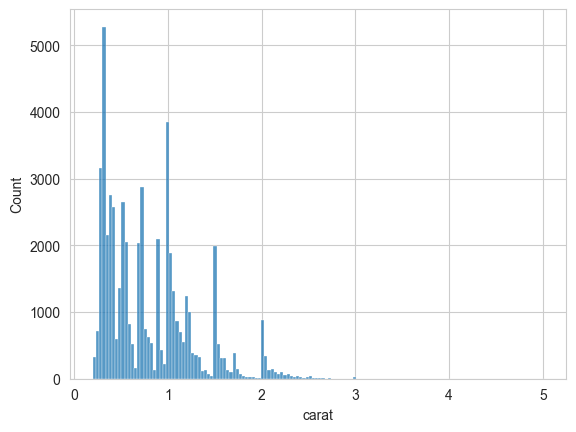

In [70]:
sns.histplot(df['carat'])

## Criando amostras aleatórias simples

Utilizaremos a função sample() que permite maior controle de parâmetros para criação da amostra aleatória.

A dica aqui, será utilizar o atributo seed (semente) para gerar a sequência aleatoriamente e garantir reprodutibilidade dos resultados em simulações e experimentos.


In [71]:
## Explique o que este código está fazendo está fazendo
np.random.seed(1)

amostra_simples = df.sample(frac=0.20)

amostra_simples.shape

(10788, 10)

np.random.seed busca uma amostra aleatória dentro do arquivo csv apresentado
amostra_simples define o tamanho da amostra, que no caso seria 20% do tamanho total do arquivo
printa o tamanho da amostra, que seria 10788 linhas e 10 colunas

In [72]:
## Explique o que este código está fazendo está fazendo
np.random.seed(2)

amostra_simples1 = df.sample(15000)

amostra_simples1.shape

(15000, 10)

faz a mesma coisa que o código acima, porém define como tamanho 15000

## Amostragem Sistemática

Aqui, seleciona-se a amostra seguindo um padrão específico pré-estabelecido. Esse método é útil quando temos uma lista organizada da população e queremos garantir uma distribuição mais uniforme dos elementos selecionados.


In [73]:
## Explique o que este código está fazendo está fazendo
np.random.seed(3)

aleatorio = np.random.choice(100)

amostra_sistematica = np.arange(aleatorio,15000,150)
amostra_sistematica

array([   24,   174,   324,   474,   624,   774,   924,  1074,  1224,
        1374,  1524,  1674,  1824,  1974,  2124,  2274,  2424,  2574,
        2724,  2874,  3024,  3174,  3324,  3474,  3624,  3774,  3924,
        4074,  4224,  4374,  4524,  4674,  4824,  4974,  5124,  5274,
        5424,  5574,  5724,  5874,  6024,  6174,  6324,  6474,  6624,
        6774,  6924,  7074,  7224,  7374,  7524,  7674,  7824,  7974,
        8124,  8274,  8424,  8574,  8724,  8874,  9024,  9174,  9324,
        9474,  9624,  9774,  9924, 10074, 10224, 10374, 10524, 10674,
       10824, 10974, 11124, 11274, 11424, 11574, 11724, 11874, 12024,
       12174, 12324, 12474, 12624, 12774, 12924, 13074, 13224, 13374,
       13524, 13674, 13824, 13974, 14124, 14274, 14424, 14574, 14724,
       14874])

a variável aleatório escolhe um número entre 1 e 100 para definir o começo do amostra_sistematica.
os parâmetros de amostra_sistematica representam o indice inicial; o indice final; o intervalo em que os indices são escolhidos

Outra forma de interessante de fazer é criando também de forma aleatória um intervalo entre os valores da sequência.

Para isso utiliza-se a função randint , que gera números inteiros aleatórios dentro do intervalo especificado pelos parâmetros de valor mínimo e máximo. Se o parâmetro de tamanho da amostra for fornecido, ela retorna um array com a quantidade especificada de números inteiros aleatórios.

In [74]:
## Explique o que este código está fazendo está fazendo
np.random.seed(4)

aleatorio = np.random.choice(10,1)
passo = np.random.randint(120,300,1)
print(passo)
amostra_sistematica2 = np.arange(aleatorio,15000,passo)
amostra_sistematica2

[249]


C:\Users\fabio\AppData\Local\Temp\ipykernel_5448\3753057145.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  amostra_sistematica2 = np.arange(aleatorio,15000,passo)


array([    7,   256,   505,   754,  1003,  1252,  1501,  1750,  1999,
        2248,  2497,  2746,  2995,  3244,  3493,  3742,  3991,  4240,
        4489,  4738,  4987,  5236,  5485,  5734,  5983,  6232,  6481,
        6730,  6979,  7228,  7477,  7726,  7975,  8224,  8473,  8722,
        8971,  9220,  9469,  9718,  9967, 10216, 10465, 10714, 10963,
       11212, 11461, 11710, 11959, 12208, 12457, 12706, 12955, 13204,
       13453, 13702, 13951, 14200, 14449, 14698, 14947])

## Amostragem Estratificada

Nessa abordagem, divide-se a população em grupos menores homogêneos, chamados estratos, com base em alguma característica comum. Depois, seleciona-se uma amostra de cada estrato, proporcionalmente ao tamanho do estrato, usando amostragem simples ou sistemática. Isso garante que a amostra seja representativa de cada subgrupo da população.

In [75]:
df['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

### Exercício 1

Divida a população, selecionando os casos pela variável 'cut', em amostras aleatórias de 20%

In [76]:
amostraIdeal = df.loc[df.cut == 'Ideal'].sample(frac=0.2)
amostraPremium = df.loc[df.cut == 'Premium'].sample(frac=0.2)
amostraVeryGood = df.loc[df.cut == 'Very Good'].sample(frac=0.2)
amostraGood = df.loc[df.cut == 'Good'].sample(frac=0.2)
amostraFair = df.loc[df.cut == 'Fair'].sample(frac=0.2)

amostraFinal =  pd.concat([amostraIdeal, amostraPremium, amostraVeryGood, amostraGood, amostraFair])
amostraFinal.shape

(10787, 10)

### Exercício 2

Faça uma amostra com 20000 entradas, mantendo a proporção da variável 'cut' tal qual o arquivo original

In [77]:
amostraIdeal = df.loc[df.cut == 'Ideal'].sample(7656)
amostraPremium = df.loc[df.cut == 'Premium'].sample(4878)
amostraVeryGood = df.loc[df.cut == 'Very Good'].sample(4433)
amostraGood = df.loc[df.cut == 'Good'].sample(1703)
amostraFair = df.loc[df.cut == 'Fair'].sample(569)

amostraFinal2 =  pd.concat([amostraIdeal, amostraPremium, amostraVeryGood, amostraGood, amostraFair])
amostraFinal2.shape

(19239, 10)

### Exercício 3

Plote histogramas para a variável quilate do arquivo original e de todas as amostras que vocês criaram em aula. Os resultados foram análogos?

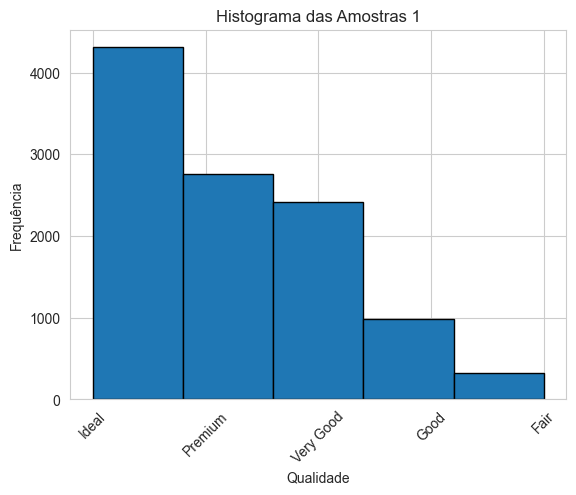

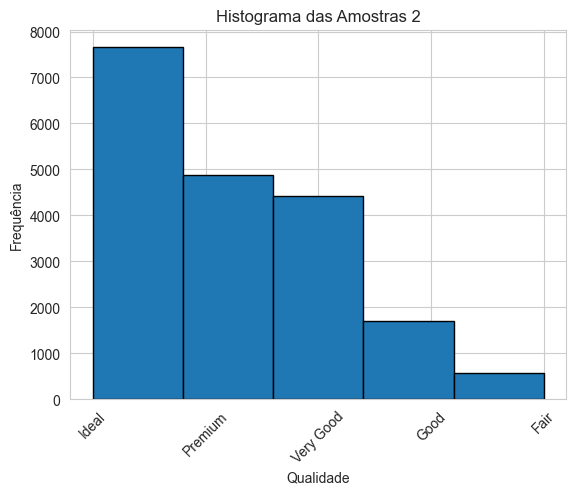

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# Plotando o histograma
plt.hist(amostraFinal['cut'], bins=5, edgecolor='black')
plt.xlabel('Qualidade')
plt.ylabel('Frequência')
plt.title('Histograma das Amostras 1')
plt.xticks(rotation=45)  # Rotacionar os rótulos do eixo x para melhor visualização
plt.show()


# Plotando o histograma
plt.hist(amostraFinal2['cut'], bins=5, edgecolor='black')
plt.xlabel('Qualidade')
plt.ylabel('Frequência')
plt.title('Histograma das Amostras 2')
plt.xticks(rotation=45)  # Rotacionar os rótulos do eixo x para melhor visualização
plt.show()

### Referência

Estatística para Análise de Dados com Python (Prof. Luciano Galdino)

https://medium.com/@pablovictords/estat%C3%ADstica-na-pr%C3%A1tica-com-python-amostragem-aleat%C3%B3ria-7f252495e042

https://icd-ufmg.github.io/08-amostragem/

